In [5]:
!pip install requests beautifulsoup4 pandas


In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://books.toscrape.com/"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

titles=[]
prices=[]
ratings=[]

books=soup.find_all("article")

for book in books:
    titles.append(book.h3.a["title"])
    prices.append(book.find("p",class_="price_color").text)
    ratings.append(book.p["class"][1])

df=pd.DataFrame({
    "Title":titles,
    "Price":prices,
    "Rating":ratings
})

print(df)

df.to_csv("books_dataset.csv",index=False)

print("Done")

                                                Title    Price Rating
0                                A Light in the Attic  Â£51.77  Three
1                                  Tipping the Velvet  Â£53.74    One
2                                          Soumission  Â£50.10    One
3                                       Sharp Objects  Â£47.82   Four
4               Sapiens: A Brief History of Humankind  Â£54.23   Five
5                                     The Requiem Red  Â£22.65    One
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34   Four
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93  Three
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60   Four
9                                     The Black Maria  Â£52.15    One
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99    Two
11                              Shakespeare's Sonnets  Â£20.66   Four
12                                        Set Me Free  Â£17.46   Five
13  Scott Pilgrim's 

import pandas as pd

df = pd.read_csv("books_dataset.csv")

df.head()


In [7]:
import pandas as pd

df = pd.read_csv("books_dataset.csv")

df.head()


,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [8]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary:")
print(df.describe(include="all"))

Rows and Columns: (20, 3)

Column Names:
Index(['Title', 'Price', 'Rating'], dtype='object')

Missing Values:
Title     0
Price     0
Rating    0
dtype: int64

Summary:
                       Title    Price Rating
count                     20       20     20
unique                    20       20      5
top     A Light in the Attic  Â£51.77    One
freq                       1        1      6


In [4]:
import pandas as pd

df = pd.read_csv("books_dataset.csv")

df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [5]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary:")
print(df.describe(include="all"))

Rows and Columns: (20, 3)

Column Names:
Index(['Title', 'Price', 'Rating'], dtype='object')

Missing Values:
Title     0
Price     0
Rating    0
dtype: int64

Summary:
                       Title    Price Rating
count                     20       20     20
unique                    20       20      5
top     A Light in the Attic  Â£51.77    One
freq                       1        1      6


In [6]:
print("Rating Distribution")

print(df["Rating"].value_counts())

Rating Distribution
Rating
One      6
Five     4
Four     4
Three    3
Two      3
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt

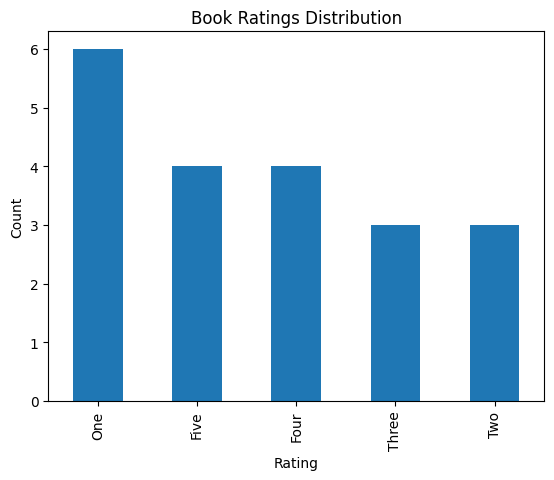

In [8]:
rating_count = df["Rating"].value_counts()

rating_count.plot(kind="bar")

plt.title("Book Ratings Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

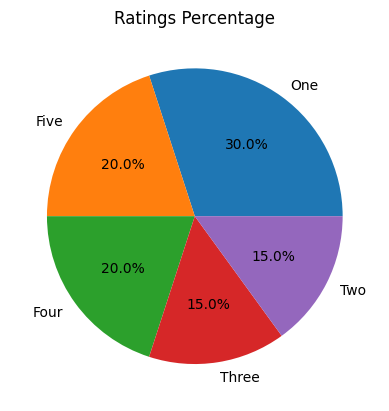

In [9]:
df["Rating"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

plt.title("Ratings Percentage")

plt.ylabel("")

plt.show()

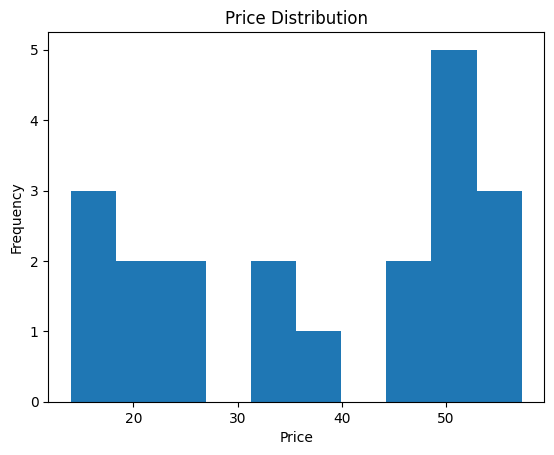

In [10]:
price = (
df["Price"]
.astype(str)
.str.replace("Â£","")
.astype(float)
)

plt.hist(price)

plt.title("Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()